In [29]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.append(str(Path.cwd().parent / "src"))
from common import PROCESSED, FIGURES, RESULTS, SEED

SHARED = ["FIFA_Points_Diff", "Stage_Level", "Rest_Days", "Home_Country_Advantage"]
ONLY_22 = ["Matches_Played_Before", "Last_Match_Points", "Last_Match_Goal_Diff", "Opp_Squad_Age"]
FEATURES = SHARED + ONLY_22
TARGET = "Goals_Scored"

df = pd.read_csv(PROCESSED / "model_task22_goals_scored.csv")
assert len(df) == 208, len(df)
assert len(FEATURES) == 8 and len(set(FEATURES)) == 8
assert len(SHARED) <= 4
missing = [c for c in FEATURES + [TARGET, "Match_ID"] if c not in df.columns]
assert not missing, f"Missing columns: {missing}"
assert df[FEATURES + [TARGET]].isna().sum().sum() == 0
assert df.groupby("Match_ID").size().eq(2).all()      # every match appears exactly twice

FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)
print(df.shape)
df[FEATURES + [TARGET]].describe().round(2).T

(208, 12)


,count,mean,std,min,25%,50%,75%,max
FIFA_Points_Diff,208.0,0.00,237.46,-506.16,-183.76,0.0,183.76,506.16
Stage_Level,208.0,1.59,1.08,1.00,1.00,1.0,2.00,6.00
Rest_Days,208.0,5.67,1.09,3.00,5.00,6.0,7.00,7.00
Home_Country_Advantage,208.0,0.06,0.24,0.00,0.00,0.0,0.00,1.00
Matches_Played_Before,208.0,1.90,1.66,0.00,1.00,2.0,3.00,7.00
Last_Match_Points,208.0,1.54,1.18,0.00,1.00,1.0,3.00,3.00
Last_Match_Goal_Diff,208.0,0.32,1.84,-6.00,0.00,0.0,1.00,6.00
Opp_Squad_Age,208.0,27.87,1.35,25.30,26.70,27.7,28.95,31.70
Goals_Scored,208.0,1.48,1.39,0.00,0.00,1.0,2.00,7.00


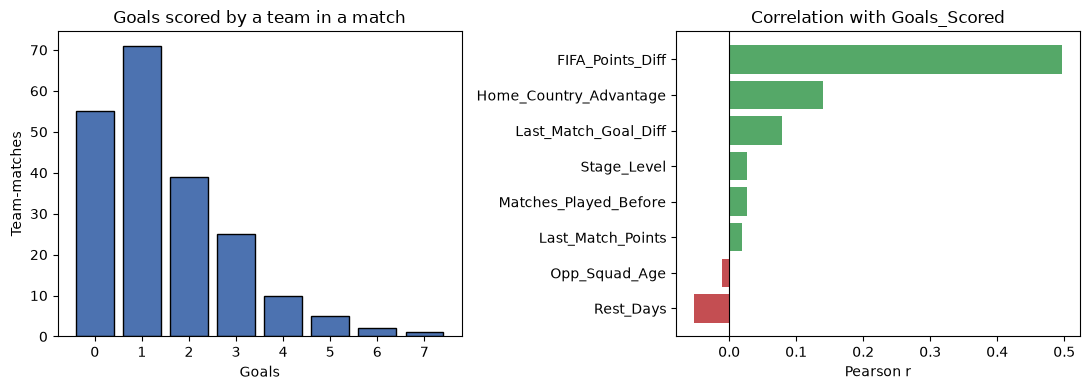

Mean goals per team-match: 1.48
Variance: 1.94
Scoreless team-matches: 55 of 208
Rest_Days                -0.05
Opp_Squad_Age            -0.01
Last_Match_Points         0.02
Matches_Played_Before     0.03
Stage_Level               0.03
Last_Match_Goal_Diff      0.08
Home_Country_Advantage    0.14
FIFA_Points_Diff          0.50


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: how many goals teams score in a match
counts = df[TARGET].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, edgecolor="black", color="#4C72B0")
axes[0].set_xticks(counts.index)
axes[0].set_title("Goals scored by a team in a match")
axes[0].set_xlabel("Goals")
axes[0].set_ylabel("Team-matches")

# Right: raw correlation of each feature with the target
corr = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
axes[1].barh(corr.index, corr.values, color=["#C44E52" if v < 0 else "#55A868" for v in corr.values])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlation with Goals_Scored")
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.savefig(FIGURES / "task22_eda.png", dpi=150)
plt.show()

print("Mean goals per team-match:", round(df[TARGET].mean(), 2))
print("Variance:", round(df[TARGET].var(), 2))
print("Scoreless team-matches:", int((df[TARGET] == 0).sum()), "of", len(df))
print(corr.round(2).to_string())

In [31]:
def fit_ols(data, features, target, groups=None):
    X = np.column_stack([np.ones(len(data)), data[features].to_numpy(float)])
    y = data[target].to_numpy(float)
    n, k = X.shape
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    resid = y - X @ beta
    sigma2 = resid @ resid / (n - k)
    se = np.sqrt(np.diag(XtX_inv) * sigma2)
    t = beta / se
    p = 2 * stats.t.sf(np.abs(t), n - k)
    tcrit = stats.t.ppf(0.975, n - k)
    r2 = 1 - resid @ resid / ((y - y.mean()) ** 2).sum()
    adj = 1 - (1 - r2) * (n - 1) / (n - k)
    f = (r2 / (k - 1)) / ((1 - r2) / (n - k))
    table = pd.DataFrame({"coef": beta, "std_err": se, "t": t, "p_value": p,
                          "ci_low": beta - tcrit * se, "ci_high": beta + tcrit * se},
                         index=["Intercept"] + list(features))
    if groups is not None:                       # cluster-robust (CR1) p-values by match
        g = np.asarray(groups)
        meat = np.zeros((k, k))
        for gid in np.unique(g):
            idx = g == gid
            sg = X[idx].T @ resid[idx]
            meat += np.outer(sg, sg)
        G = len(np.unique(g))
        c = G / (G - 1) * (n - 1) / (n - k)
        se_c = np.sqrt(np.diag(c * XtX_inv @ meat @ XtX_inv))
        table["p_value_clustered"] = 2 * stats.t.sf(np.abs(beta / se_c), G - 1)
    stats_out = dict(r2=r2, adj_r2=adj, f=f, f_p=stats.f.sf(f, k - 1, n - k),
                     n=n, k=k - 1, resid=resid, fitted=X @ beta)
    return table, stats_out

table, s = fit_ols(df, FEATURES, TARGET, groups=df["Match_ID"])
table.round(3).to_csv(RESULTS / "task22_ols_table.csv")
print(table.round(3).to_string())
print(f"\nR2 = {s['r2']:.3f} | Adj R2 = {s['adj_r2']:.3f} | F = {s['f']:.2f} (p = {s['f_p']:.2g}) | n = {s['n']}")

                         coef  std_err      t  p_value  ci_low  ci_high  p_value_clustered
Intercept               3.516    2.007  1.752    0.081  -0.442    7.474              0.123
FIFA_Points_Diff        0.003    0.000  8.056    0.000   0.002    0.004              0.000
Stage_Level             0.150    0.209  0.717    0.474  -0.263    0.563              0.506
Rest_Days              -0.137    0.136 -1.009    0.314  -0.404    0.131              0.288
Home_Country_Advantage  0.639    0.363  1.759    0.080  -0.077    1.355              0.140
Matches_Played_Before  -0.077    0.176 -0.439    0.661  -0.423    0.269              0.667
Last_Match_Points      -0.271    0.139 -1.947    0.053  -0.546    0.003              0.111
Last_Match_Goal_Diff    0.094    0.084  1.109    0.269  -0.073    0.260              0.196
Opp_Squad_Age          -0.036    0.063 -0.571    0.569  -0.160    0.088              0.613

R2 = 0.276 | Adj R2 = 0.247 | F = 9.47 (p = 4.5e-11) | n = 208


In [32]:
EXPECTED = {"FIFA_Points_Diff": "+", "Stage_Level": "-", "Rest_Days": "+",
            "Home_Country_Advantage": "+", "Matches_Played_Before": "?",
            "Last_Match_Points": "+", "Last_Match_Goal_Diff": "+", "Opp_Squad_Age": "?"}

rows = []
for f_ in FEATURES:
    b, p, pc = table.loc[f_, "coef"], table.loc[f_, "p_value"], table.loc[f_, "p_value_clustered"]
    sign = "+" if b > 0 else "-"
    exp = EXPECTED[f_]
    direction = "no expectation" if exp == "?" else ("as expected" if exp == sign else "OPPOSITE")
    rows.append({"variable": f_, "expected": exp, "coef": round(b, 3),
                 "p_value": round(p, 3), "p_clustered": round(pc, 3),
                 "decision (5%)": "Reject H0" if p < 0.05 else "Fail to reject H0",
                 "same under clustering?": "yes" if (p < 0.05) == (pc < 0.05) else "NO",
                 "direction": direction})

hyp_results = pd.DataFrame(rows)
hyp_results.to_csv(RESULTS / "task22_hypotheses_vs_results.csv", index=False)
print(hyp_results.to_string(index=False))

              variable expected   coef  p_value  p_clustered     decision (5%) same under clustering?      direction
      FIFA_Points_Diff        +  0.003    0.000        0.000         Reject H0                    yes    as expected
           Stage_Level        -  0.150    0.474        0.506 Fail to reject H0                    yes       OPPOSITE
             Rest_Days        + -0.137    0.314        0.288 Fail to reject H0                    yes       OPPOSITE
Home_Country_Advantage        +  0.639    0.080        0.140 Fail to reject H0                    yes    as expected
 Matches_Played_Before        ? -0.077    0.661        0.667 Fail to reject H0                    yes no expectation
     Last_Match_Points        + -0.271    0.053        0.111 Fail to reject H0                    yes       OPPOSITE
  Last_Match_Goal_Diff        +  0.094    0.269        0.196 Fail to reject H0                    yes    as expected
         Opp_Squad_Age        ? -0.036    0.569        0.613 Fai

In [33]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

def repeated_group_splits(groups, n_splits=5, n_repeats=10, seed=SEED):
    """Repeated K-fold where all rows of a group (match) stay in the same fold."""
    rng = np.random.default_rng(seed)
    groups = np.asarray(groups)
    uniq = np.unique(groups)
    splits = []
    for _ in range(n_repeats):
        fold_of = dict(zip(rng.permutation(uniq), np.arange(len(uniq)) % n_splits))
        folds = np.array([fold_of[g] for g in groups])
        for k in range(n_splits):
            splits.append((np.where(folds != k)[0], np.where(folds == k)[0]))
    return splits

X, y = df[FEATURES], df[TARGET]
splits = repeated_group_splits(df["Match_ID"])

# Leakage check: no match appears in both train and test
for tr, te in splits:
    assert set(df["Match_ID"].iloc[tr]).isdisjoint(set(df["Match_ID"].iloc[te]))

models = {
    "Baseline (mean)": DummyRegressor(strategy="mean"),
    "OLS": LinearRegression(),
    "Ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30))),
    "Lasso": make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=SEED, max_iter=20000)),
    "Random forest": RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                                           random_state=SEED, n_jobs=-1),
}

rows = []
for name, model in models.items():
    r = cross_validate(model, X, y, cv=splits,
                       scoring=("neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"))
    rows.append({"model": name,
                 "RMSE": -r["test_neg_root_mean_squared_error"].mean(),
                 "RMSE_sd": r["test_neg_root_mean_squared_error"].std(),
                 "MAE": -r["test_neg_mean_absolute_error"].mean(),
                 "R2": r["test_r2"].mean()})

cv_results = pd.DataFrame(rows).round(3)
cv_results.to_csv(RESULTS / "task22_model_comparison.csv", index=False)
print(cv_results.to_string(index=False))
print("Number of train/test splits:", len(splits))

          model  RMSE  RMSE_sd   MAE     R2
Baseline (mean) 1.385    0.175 1.115 -0.029
            OLS 1.247    0.155 0.961  0.159
          Ridge 1.239    0.164 0.953  0.174
          Lasso 1.229    0.163 0.941  0.189
  Random forest 1.268    0.175 0.943  0.130
Number of train/test splits: 50


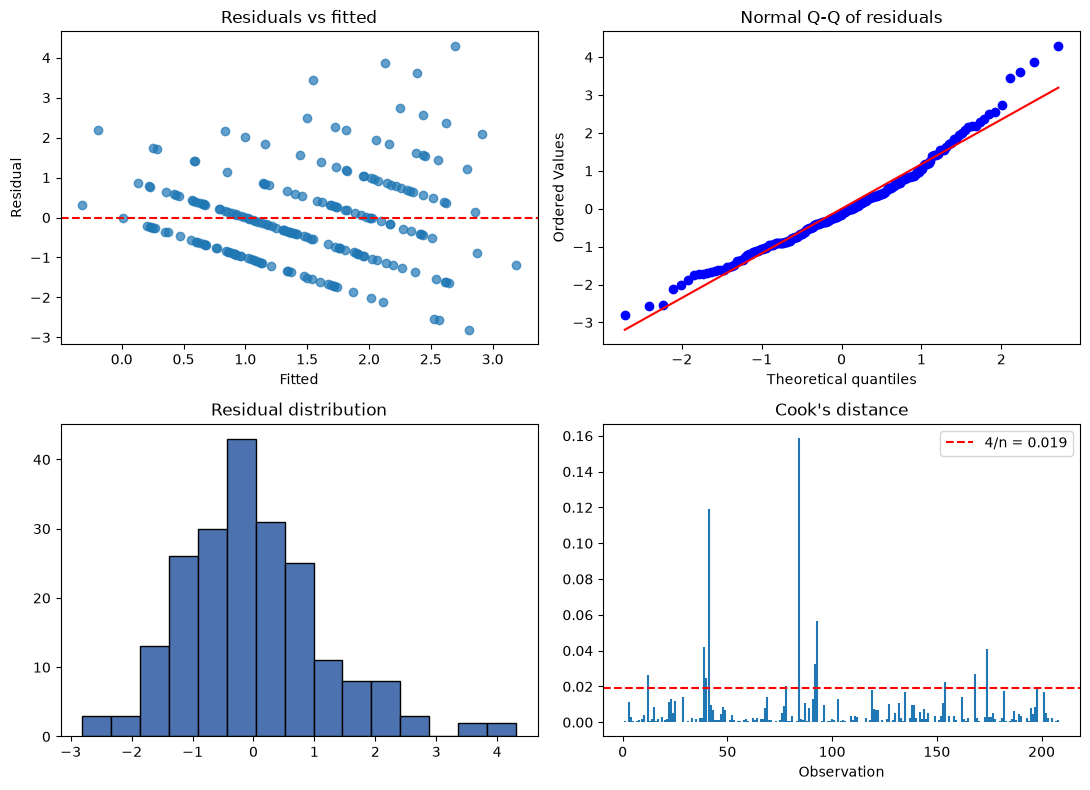

Shapiro-Wilk  W = 0.970, p = 0.000
Breusch-Pagan LM = 26.02, p = 0.001
Within-match residual correlation r = 0.16, p = 0.116

VIF:
FIFA_Points_Diff           1.06
Stage_Level                7.26
Rest_Days                  3.09
Home_Country_Advantage     1.10
Matches_Played_Before     12.00
Last_Match_Points          3.82
Last_Match_Goal_Diff       3.41
Opp_Squad_Age              1.03

Influential rows (Cook's D > 4/n): 11
 Match_ID       Team  Goals_Scored  cooks
      103    England             6  0.159
       27     Canada             6  0.119
        9    Germany             7  0.057
       87 Cabo Verde             2  0.042
       14      Spain             0  0.041
      103     France             4  0.033
      104  Argentina             0  0.027
       62    Senegal             5  0.027


In [34]:
resid, fitted = s["resid"], s["fitted"]
n_obs, k = s["n"], s["k"] + 1                     # k includes the intercept

# 1) Normality of residuals
sw_stat, sw_p = stats.shapiro(resid)

# 2) Constant variance: Breusch-Pagan (LM form)
Xc = np.column_stack([np.ones(n_obs), df[FEATURES].to_numpy(float)])
e2 = resid ** 2
g = np.linalg.lstsq(Xc, e2, rcond=None)[0]
r2_aux = 1 - ((e2 - Xc @ g) ** 2).sum() / ((e2 - e2.mean()) ** 2).sum()
bp_stat = n_obs * r2_aux
bp_p = stats.chi2.sf(bp_stat, k - 1)

# 3) Multicollinearity: VIF
Xf = df[FEATURES].to_numpy(float)
vifs = {}
for j, f in enumerate(FEATURES):
    others = np.column_stack([np.ones(n_obs), np.delete(Xf, j, axis=1)])
    b = np.linalg.lstsq(others, Xf[:, j], rcond=None)[0]
    r2j = 1 - ((Xf[:, j] - others @ b) ** 2).sum() / ((Xf[:, j] - Xf[:, j].mean()) ** 2).sum()
    vifs[f] = 1 / (1 - r2j)

# 4) Independence: do the two rows of the same match have correlated residuals?
pair = pd.DataFrame({"m": df["Match_ID"].values, "r": resid})
pair["i"] = pair.groupby("m").cumcount()
wide = pair.pivot(index="m", columns="i", values="r")
within_r, within_p = stats.pearsonr(wide[0], wide[1])

# 5) Influential observations: Cook's distance
h = np.diag(Xc @ np.linalg.inv(Xc.T @ Xc) @ Xc.T)
mse = (resid @ resid) / (n_obs - k)
cooks = resid ** 2 / (k * mse) * h / (1 - h) ** 2
thr = 4 / n_obs

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
ax[0, 0].scatter(fitted, resid, alpha=0.7)
ax[0, 0].axhline(0, color="red", ls="--")
ax[0, 0].set_title("Residuals vs fitted"); ax[0, 0].set_xlabel("Fitted"); ax[0, 0].set_ylabel("Residual")
stats.probplot(resid, dist="norm", plot=ax[0, 1]); ax[0, 1].set_title("Normal Q-Q of residuals")
ax[1, 0].hist(resid, bins=15, edgecolor="black", color="#4C72B0"); ax[1, 0].set_title("Residual distribution")
ax[1, 1].stem(np.arange(1, n_obs + 1), cooks, markerfmt=" ", basefmt=" ")
ax[1, 1].axhline(thr, color="red", ls="--", label=f"4/n = {thr:.3f}")
ax[1, 1].set_title("Cook's distance"); ax[1, 1].set_xlabel("Observation"); ax[1, 1].legend()
plt.tight_layout()
plt.savefig(FIGURES / "task22_diagnostics.png", dpi=150)
plt.show()

print(f"Shapiro-Wilk  W = {sw_stat:.3f}, p = {sw_p:.3f}")
print(f"Breusch-Pagan LM = {bp_stat:.2f}, p = {bp_p:.3f}")
print(f"Within-match residual correlation r = {within_r:.2f}, p = {within_p:.3f}")
print("\nVIF:"); print(pd.Series(vifs).round(2).to_string())
inf = df.loc[cooks > thr, ["Match_ID", "Team", TARGET]].assign(cooks=cooks[cooks > thr].round(3))
print(f"\nInfluential rows (Cook's D > 4/n): {len(inf)}")
print(inf.sort_values("cooks", ascending=False).head(8).to_string(index=False))

In [35]:
from sklearn.linear_model import LinearRegression

d = df.copy()
d["Last_Match_Win"] = (d["Last_Match_Points"] == 3).astype(int)
d["Last_Match_GD_Capped"] = d["Last_Match_Goal_Diff"].clip(-3, 3)
d["Opp_Age_Distance"] = (d["Opp_Squad_Age"] - d["Opp_Squad_Age"].mean()).abs()

def swap(cols, old, new):
    return [new if c == old else c for c in cols]

VARIANTS = {
    "A. Original 8": FEATURES,
    "B. Last_Match_Points -> Last_Match_Win": swap(FEATURES, "Last_Match_Points", "Last_Match_Win"),
    "C. Last_Match_Goal_Diff -> capped at +/-3": swap(FEATURES, "Last_Match_Goal_Diff", "Last_Match_GD_Capped"),
    "D. Opp_Squad_Age -> distance from average age": swap(FEATURES, "Opp_Squad_Age", "Opp_Age_Distance"),
    "E. B + C together": swap(swap(FEATURES, "Last_Match_Points", "Last_Match_Win"),
                              "Last_Match_Goal_Diff", "Last_Match_GD_Capped"),
}

splits = repeated_group_splits(d["Match_ID"], n_repeats=20)
rows = []
for name, cols in VARIANTS.items():
    assert len(cols) == 8 and len(set(cols)) == 8, name       # never more than 8
    r = cross_validate(LinearRegression(), d[cols], d[TARGET], cv=splits,
                       scoring=("neg_root_mean_squared_error", "r2"))
    rows.append({"variant": name,
                 "RMSE": -r["test_neg_root_mean_squared_error"].mean(),
                 "R2": r["test_r2"].mean()})

opt = pd.DataFrame(rows)
opt["RMSE_change_vs_A"] = opt["RMSE"] - opt.loc[0, "RMSE"]
opt.round(3).to_csv(RESULTS / "task22_optimisation.csv", index=False)
print(opt.round(3).to_string(index=False))
print("\nBest variant:", opt.loc[opt["RMSE"].idxmin(), "variant"])

                                      variant  RMSE    R2  RMSE_change_vs_A
                                A. Original 8 1.255 0.144             0.000
       B. Last_Match_Points -> Last_Match_Win 1.245 0.157            -0.010
    C. Last_Match_Goal_Diff -> capped at +/-3 1.257 0.141             0.002
D. Opp_Squad_Age -> distance from average age 1.249 0.152            -0.006
                            E. B + C together 1.246 0.155            -0.009

Best variant: B. Last_Match_Points -> Last_Match_Win


In [ ]:
## Task 2.2 Summary: Limitations and Alternatives

## Findings.** With eight pre-match variables, the OLS model explains about 28% of the variance in goals scored in-sample (Adj R² ≈ 0.25), and about 16% in grouped cross-validation (RMSE ≈ 1.25 goals vs 1.39 for always predicting the mean). `FIFA_Points_Diff` is the only variable for which H0 is rejected at the 5% level (p < 0.001, positive, as hypothesised); the other seven hypotheses are not supported, also under match-clustered standard errors. `Last_Match_Points` has a sign opposite to our hypothesis and is borderline (p = 0.053, clustered p = 0.111), and `Home_Country_Advantage` is positive (about +0.6 goals) but rests on only 13 of 208 rows (p = 0.08).

## Validation and alternatives.** All cross-validation used folds grouped by `Match_ID`, so no match appears in both training and test sets. Ridge, Lasso and a random forest were compared with OLS: Lasso was nominally best (RMSE 1.229 vs 1.247 for OLS), but differences between models (about 0.04) are far smaller than fold-to-fold variation (SD ≈ 0.16), so the simple linear model is sufficient. Re-coding individual task-specific variables (best: win flag instead of last-match points, RMSE −0.010) gave no meaningful improvement, so we do not claim one; every variant replaced a variable, keeping exactly 8.

##Assumption checks.** Residuals are non-normal (Shapiro-Wilk p < 0.001) and heteroscedastic (Breusch-Pagan p = 0.001), which is expected for a discrete, right-skewed count of goals; p-values should therefore be read as approximate. Residuals of the two teams in the same match are only mildly correlated (r = 0.16, p = 0.12). No single observation dominates (largest Cook's D ≈ 0.16).

## Multicollinearity.** `Matches_Played_Before` (VIF ≈ 12) and `Stage_Level` (VIF ≈ 7) are strongly collinear, because later matches mean more matches already played. This inflates their standard errors and explains why `Stage_Level` shows an unexpected sign and no significant effect; we therefore do not interpret these two coefficients individually. A sensitivity refit without `Matches_Played_Before` (Cell 8b) was run to check that the other coefficients are not distorted.

##Limitations.**
# - 208 team-matches from a single tournament; the two rows of each match share the same game conditions.
# - Early-tournament form variables rest on very few matches (shrunk towards a prior) and carry little information.
# - Goals scored is a count; a Poisson or negative-binomial model would be the natural alternative to linear regression, but the brief requires linear regression.
# - Football outcomes are highly random, so most of the variance remains unexplained by pre-match information.
# - Only 4 of the 8 variables are shared with Task 2.1, as required, which constrains how closely the two models can mirror each other.

SyntaxError: invalid character '²' (U+00B2) (641299678.py, line 3)